# Scene 2 Experimental OpenAI Realization Notebook

In [1]:
%cd /content
!git clone https://github.com/UrbinaDan/PaperTheater_ai_Pipeline.git
%cd PaperTheater_ai_Pipeline

!pip install -q numpy scipy matplotlib opencv-python-headless pillow shapely svgwrite cairosvg tqdm networkx pyyaml requests openai accelerate bitsandbytes einops sentencepiece transformers==4.49.0


/content
Cloning into 'PaperTheater_ai_Pipeline'...
remote: Enumerating objects: 156, done.
remote: Counting objects: 100% (156/156), done.
remote: Compressing objects: 100% (133/133), done.
remote: Total 156 (delta 85), reused 72 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (156/156), 17.31 MiB | 13.73 MiB/s, done.
Resolving deltas: 100% (85/85), done.
/content/PaperTheater_ai_Pipeline
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os
from getpass import getpass
os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI key: ")


Enter your OpenAI key: ··········


In [3]:
%cd /content
!git clone https://github.com/facebookresearch/sam2.git
%cd sam2
!pip install -e .
!mkdir -p checkpoints
!wget -q -P checkpoints https://dl.fbaipublicfiles.com/segment_anything_2/072824/sam2_hiera_small.pt
!wget -q -P checkpoints https://raw.githubusercontent.com/facebookresearch/sam2/main/sam2_configs/sam2_hiera_s.yaml

%cd /content
!git clone https://github.com/DepthAnything/Depth-Anything-V2.git
%cd Depth-Anything-V2
!mkdir -p checkpoints
!wget -q -P checkpoints https://huggingface.co/depth-anything/Depth-Anything-V2-Small/resolve/main/depth_anything_v2_vits.pth


/content
Cloning into 'sam2'...
remote: Enumerating objects: 1091, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 1091 (delta 7), reused 4 (delta 4), pack-reused 1080 (from 4)
Receiving objects: 100% (1091/1091), 128.27 MiB | 26.08 MiB/s, done.
Resolving deltas: 100% (390/390), done.
/content/sam2
Obtaining file:///content/sam2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.7 MB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done
  Created wheel for SAM-2: filename=sam_2-1.0-0.editable-cp312-cp312-linux_x86_64.whl size=13850 sha256=ea50e6ba97bc7c44e8b3e9f68f86b2e21a9

In [18]:
%cd /content/PaperTheater_ai_Pipeline

import importlib, shutil
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from src.config import Paths, PipelineConfig
from src.io_utils import ensure_dirs, load_image, save_mask
from src.florence_parser import FlorenceParser
from src.sam2_segmenter import SAM2Segmenter
from src.depth_anything_runner import DepthRunner
from src.occlusion_heuristic import heuristic_complete
from src.mask_cleanup import cleanup_mask

from src.scene_builder import parse_florence_boxes, merge_segmented_by_label, build_stable_merged_objects
from src.scene_representation import build_scene_representation
from src.layer_planner import plan_layers_deterministic
# importlib.reload(src.layer_renderer)
from src.layer_renderer import build_object_mask_map
from src.layer_context_builder import build_layer_contexts
from src.layer_realization_openai import realize_single_layer_experimental

import src.occlusion_openai
importlib.reload(src.occlusion_openai)
openai_edit = src.occlusion_openai.openai_edit

paths = Paths()
cfg = PipelineConfig()
ensure_dirs(paths)


/content/PaperTheater_ai_Pipeline


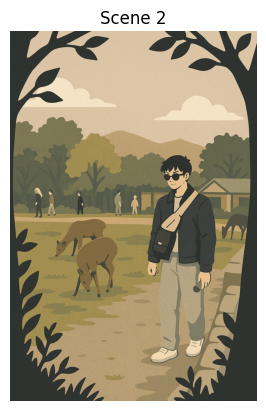

In [68]:
SCENE_NAME = "scene_2"

image_path = f"/content/PaperTheater_ai_Pipeline/data/input/{SCENE_NAME}.jpg"

image = load_image(image_path, max_side=cfg.image_max_side)

plt.imshow(image)
plt.axis("off")
plt.title("Scene 2")
plt.show()


In [69]:
florence = FlorenceParser(cfg.florence_model)
segmenter = SAM2Segmenter(cfg.sam2_config, cfg.sam2_checkpoint)
depth_runner = DepthRunner(cfg.depth_encoder)

caption = florence.get_dense_caption(image)
print(caption)

# det = florence.get_open_vocab_detection(
#     image,
#     "a person, deer, trees, branches, bushes, grass, path, building, sky, clouds"
# )

det = florence.get_open_vocab_detection(
    image,
    "a person, deer, tree branches, trees, building, sky"
)

{'<MORE_DETAILED_CAPTION>': 'The image is an illustration of a young man standing in a park. He is wearing a black jacket, white pants, and sunglasses. He has a backpack slung over his shoulder and is holding a camera in his right hand. In the background, there are several deer grazing on the grass. The park is surrounded by trees and there are a few people walking around. The sky is blue with white clouds and the overall mood of the image is peaceful and serene.'}


In [63]:
print(det)

{'<OPEN_VOCABULARY_DETECTION>a person, deer, tree branches, trees, building, sky': 'a person, deer, tree branches, trees, building, sky<loc_0><loc_0><loc_998><loc_998>'}


In [71]:
queries = [
    "a person",
    "a deer",
    "tree branches",
    "trees",
    "a building",
    "the sky",
]

all_boxes = []

for q in queries:
    det_q = florence.get_open_vocab_detection(image, q)
    boxes_q = parse_florence_boxes(det_q, image.shape)

    print("\nQUERY:", q)
    print("RAW:", det_q)
    print("PARSED:", boxes_q)

    all_boxes.extend(boxes_q)

boxes = all_boxes
print("\nFINAL BOXES:")
print(boxes)
print("num boxes:", len(boxes))


QUERY: a person
RAW: {'<OPEN_VOCABULARY_DETECTION>a person': 'a person<loc_552><loc_333><loc_841><loc_902>'}
PARSED: [{'label': 'person', 'bbox': [565, 512, 862, 1386]}]

QUERY: a deer
RAW: {'<OPEN_VOCABULARY_DETECTION>a deer': 'a deer<loc_250><loc_555><loc_444><loc_726>a deer<loc_178><loc_506><loc_397><loc_616>'}
PARSED: [{'label': 'deer', 'bbox': [182, 777, 406, 947]}, {'label': 'deer', 'bbox': [256, 853, 455, 1116]}]

QUERY: tree branches
RAW: {'<OPEN_VOCABULARY_DETECTION>tree branches': 'tree branches<loc_0><loc_0><loc_998><loc_998>'}
PARSED: []

QUERY: trees
RAW: {'<OPEN_VOCABULARY_DETECTION>trees': 'trees<loc_13><loc_231><loc_973><loc_497>trees<loc_220><loc_273><loc_458><loc_484>trees<loc_760><loc_273><loc_974><loc_417>'}
PARSED: [{'label': 'trees', 'bbox': [13, 355, 997, 764]}]

QUERY: a building
RAW: {'<OPEN_VOCABULARY_DETECTION>a building': 'a building<loc_760><loc_396><loc_977><loc_496>'}
PARSED: [{'label': 'temple', 'bbox': [779, 608, 1001, 762]}]

QUERY: the sky
RAW: {'<OP

In [83]:
def clip_boxes_to_image(boxes, image_shape):
    h, w = image_shape[:2]
    clipped = []

    for b in boxes:
        x1, y1, x2, y2 = b["bbox"]

        x1 = max(0, min(x1, w - 1))
        y1 = max(0, min(y1, h - 1))
        x2 = max(0, min(x2, w - 1))
        y2 = max(0, min(y2, h - 1))

        # make sure box still has area
        if x2 > x1 and y2 > y1:
            clipped.append({
                "label": b["label"],
                "bbox": [x1, y1, x2, y2]
            })

    return clipped

In [84]:
print("image shape:", image.shape)
print("boxes before clipping:")
for b in boxes:
    print(b)

boxes = clip_boxes_to_image(boxes, image.shape)

print("\nboxes after clipping:")
for b in boxes:
    print(b)

segmented = segmenter.segment_boxes(image, boxes)
print("num segmented:", len(segmented))

image shape: (1536, 1024, 3)
boxes before clipping:
{'label': 'person', 'bbox': [565, 512, 862, 1386]}
{'label': 'deer', 'bbox': [182, 777, 406, 947]}
{'label': 'deer', 'bbox': [256, 853, 455, 1116]}
{'label': 'trees', 'bbox': [13, 355, 997, 764]}
{'label': 'temple', 'bbox': [779, 608, 1001, 762]}
{'label': 'sky', 'bbox': [0, 0, 1022, 476]}

boxes after clipping:
{'label': 'person', 'bbox': [565, 512, 862, 1386]}
{'label': 'deer', 'bbox': [182, 777, 406, 947]}
{'label': 'deer', 'bbox': [256, 853, 455, 1116]}
{'label': 'trees', 'bbox': [13, 355, 997, 764]}
{'label': 'temple', 'bbox': [779, 608, 1001, 762]}
{'label': 'sky', 'bbox': [0, 0, 1022, 476]}
num segmented: 6


In [91]:
merged_segmented = merge_segmented_by_label(segmented)
print("num merged_segmented:", len(merged_segmented))

depth = depth_runner.infer(image)
stable_objects = build_stable_merged_objects(merged_segmented, depth)
print("num stable_objects:", len(stable_objects))

num merged_segmented: 5
num stable_objects: 5


In [92]:
print("\nSegmented labels:")
for s in segmented:
    print(s["label"], s["bbox"], s["mask"].sum())

print("\nMerged labels:")
for m in merged_segmented:
    print(m["label"], m["bbox"], m["mask"].sum())

print("\nStable objects:")
for obj in stable_objects:
    print(obj["id"], obj["label"], obj["bbox"], obj["area"])


Segmented labels:
person [565, 512, 862, 1386] 159272
deer [182, 777, 406, 947] 15525
deer [256, 853, 455, 1116] 26461
trees [13, 355, 997, 764] 238247
temple [779, 608, 1001, 762] 20244
sky [0, 0, 1022, 476] 361745

Merged labels:
person [565, 512, 862, 1386] 159272
deer [182, 777, 455, 1116] 41986
trees [13, 355, 997, 764] 238247
temple [779, 608, 1001, 762] 20244
sky [0, 0, 1022, 476] 361745

Stable objects:
obj_000 person [565, 512, 862, 1386] 159272
obj_001 deer [182, 777, 455, 1116] 41986
obj_002 trees [13, 355, 997, 764] 238247
obj_003 temple [779, 608, 1001, 762] 20244
obj_004 sky [0, 0, 1022, 476] 361745


In [72]:
print("boxes:", boxes)
print("num boxes:", len(boxes))

boxes: [{'label': 'person', 'bbox': [565, 512, 862, 1386]}, {'label': 'deer', 'bbox': [182, 777, 406, 947]}, {'label': 'deer', 'bbox': [256, 853, 455, 1116]}, {'label': 'trees', 'bbox': [13, 355, 997, 764]}, {'label': 'temple', 'bbox': [779, 608, 1001, 762]}, {'label': 'sky', 'bbox': [0, 0, 1022, 476]}]
num boxes: 6


In [93]:
print("num boxes:", len(boxes))
print("num segmented:", len(segmented))
print("num merged_segmented:", len(merged_segmented))
print("num stable_objects:", len(stable_objects))

print("\nBoxes:")
for b in boxes[:20]:
    print(b)

print("\nMerged labels:")
for m in merged_segmented:
    print(m["label"], m["bbox"])

print("\nStable objects:")
for obj in stable_objects:
    print(obj["id"], obj["label"], obj["bbox"], obj["area"])

num boxes: 6
num segmented: 6
num merged_segmented: 5
num stable_objects: 5

Boxes:
{'label': 'person', 'bbox': [565, 512, 862, 1386]}
{'label': 'deer', 'bbox': [182, 777, 406, 947]}
{'label': 'deer', 'bbox': [256, 853, 455, 1116]}
{'label': 'trees', 'bbox': [13, 355, 997, 764]}
{'label': 'temple', 'bbox': [779, 608, 1001, 762]}
{'label': 'sky', 'bbox': [0, 0, 1022, 476]}

Merged labels:
person [565, 512, 862, 1386]
deer [182, 777, 455, 1116]
trees [13, 355, 997, 764]
temple [779, 608, 1001, 762]
sky [0, 0, 1022, 476]

Stable objects:
obj_000 person [565, 512, 862, 1386] 159272
obj_001 deer [182, 777, 455, 1116] 41986
obj_002 trees [13, 355, 997, 764] 238247
obj_003 temple [779, 608, 1001, 762] 20244
obj_004 sky [0, 0, 1022, 476] 361745


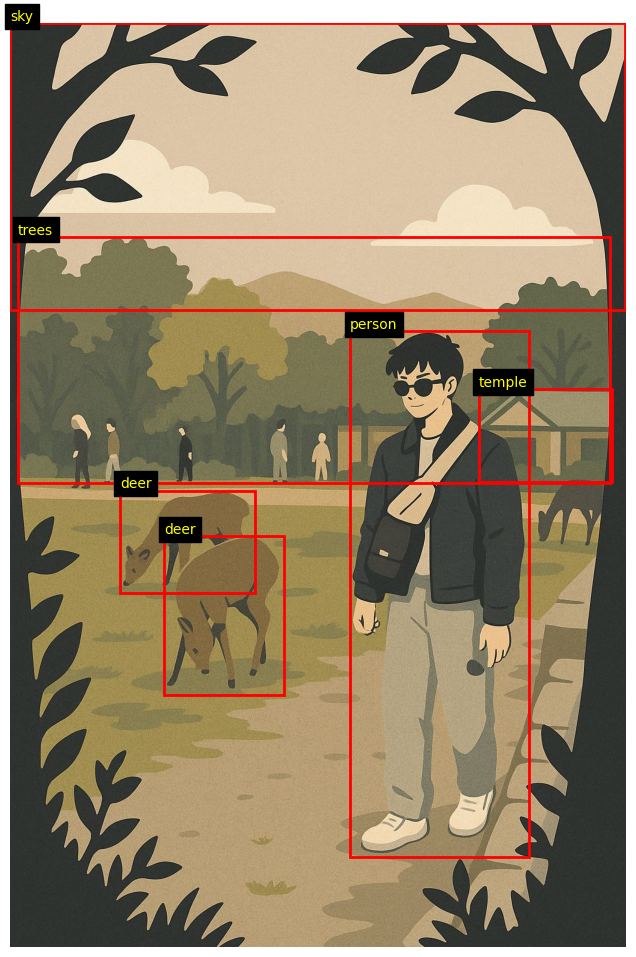

In [94]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(image)

for b in boxes:
    x1, y1, x2, y2 = b["bbox"]
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor="red", facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(x1, y1 - 5, b["label"], color="yellow", fontsize=10, backgroundcolor="black")

ax.axis("off")
plt.show()

In [74]:
print(depth)

[[0.9911909  0.9867237  0.9823889  ... 0.8774385  0.78979045 0.70006293]
 [0.9899584  0.9856662  0.98144925 ... 0.86525863 0.81102365 0.75554824]
 [0.9887809  0.9846501  0.9805429  ... 0.85375863 0.8319726  0.80976003]
 ...
 [0.9752798  0.973198   0.9711806  ... 0.96369386 0.9620405  0.96033764]
 [0.9659692  0.96910006 0.9721123  ... 0.9637858  0.96326345 0.9627006 ]
 [0.95616114 0.9647777  0.9730839  ... 0.96380043 0.9644946  0.96515846]]


In [95]:
scene_repr = build_scene_representation(
    image_path=image_path,
    image_shape=image.shape,
    caption=caption,
    stable_objects=stable_objects,
)

layer_plan = plan_layers_deterministic(scene_repr)


In [96]:
print(layer_plan)

{'layers': [{'name': 'background_sky', 'object_ids': ['obj_004'], 'order': 0}, {'name': 'layer_trees', 'object_ids': ['obj_002'], 'order': 1}, {'name': 'temple_main', 'object_ids': ['obj_003'], 'order': 2}, {'name': 'layer_deer', 'object_ids': ['obj_001'], 'order': 3}, {'name': 'layer_person', 'object_ids': ['obj_000'], 'order': 4}]}


In [97]:
openai_results = []

for obj in stable_objects:
    mask = obj["mask"]
    label = obj["label"]
    cleaned_mask = cleanup_mask(heuristic_complete(mask, label), cfg.min_component_area, cfg.smooth_kernel)

    out_mask = paths.completed_dir / f"{SCENE_NAME}_mask_{obj['id']}.png"
    save_mask(out_mask, cleaned_mask)

    openai_results.append({
        "id": obj["id"],
        "label": label,
        "bbox": obj["bbox"],
        "mask_path": str(out_mask)
    })


In [98]:
print(openai_results)

[{'id': 'obj_000', 'label': 'person', 'bbox': [565, 512, 862, 1386], 'mask_path': '/content/PaperTheater_ai_Pipeline/data/intermediate/completed/scene_2_mask_obj_000.png'}, {'id': 'obj_001', 'label': 'deer', 'bbox': [182, 777, 455, 1116], 'mask_path': '/content/PaperTheater_ai_Pipeline/data/intermediate/completed/scene_2_mask_obj_001.png'}, {'id': 'obj_002', 'label': 'trees', 'bbox': [13, 355, 997, 764], 'mask_path': '/content/PaperTheater_ai_Pipeline/data/intermediate/completed/scene_2_mask_obj_002.png'}, {'id': 'obj_003', 'label': 'temple', 'bbox': [779, 608, 1001, 762], 'mask_path': '/content/PaperTheater_ai_Pipeline/data/intermediate/completed/scene_2_mask_obj_003.png'}, {'id': 'obj_004', 'label': 'sky', 'bbox': [0, 0, 1022, 476], 'mask_path': '/content/PaperTheater_ai_Pipeline/data/intermediate/completed/scene_2_mask_obj_004.png'}]


In [99]:
object_mask_map = build_object_mask_map(openai_results)

layer_contexts = build_layer_contexts(
    scene_repr=scene_repr,
    layer_plan=layer_plan,
    object_mask_map=object_mask_map,
)


In [100]:
def apply_focus_mask(img, own, front):
    out = img.copy()
    out[~(own>0)] = 0
    out[(front>0)] = 0
    return out

def experimental_layer_openai_fn(image_crop, ownership_mask_crop, front_occlusion_mask_crop, layer_context, prompt, model_name):
    focused = apply_focus_mask(image_crop, ownership_mask_crop, front_occlusion_mask_crop)
    return openai_edit(focused, ownership_mask_crop, layer_context["labels"][0], model_name, prompt=prompt)


In [101]:
all_results = []

for ctx in layer_contexts:
    label = ctx["labels"][0] if ctx["labels"] else ctx["layer_name"]

    prompt = f"Generate only the {label} layer. No extra objects. Respect mask."

    result = realize_single_layer_experimental(
        image=image,
        layer_context=ctx,
        prompt=prompt,
        output_dir="/content/experimental_scene2",
        openai_realize_fn=experimental_layer_openai_fn,
        model_name=cfg.openai_model,
        pad=8,
    )

    all_results.append(result)
    print(result["generated_visible_crop_path"])


/content/experimental_scene2/00_background_sky_generated_visible_crop.png
/content/experimental_scene2/01_layer_trees_generated_visible_crop.png
/content/experimental_scene2/02_temple_main_generated_visible_crop.png
/content/experimental_scene2/03_layer_deer_generated_visible_crop.png
/content/experimental_scene2/04_layer_person_generated_visible_crop.png


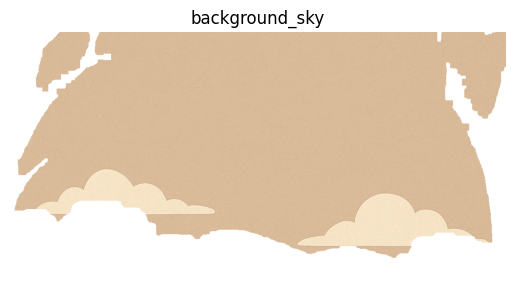

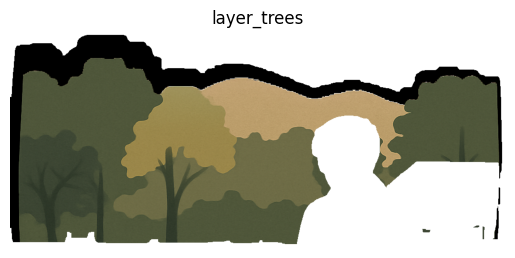

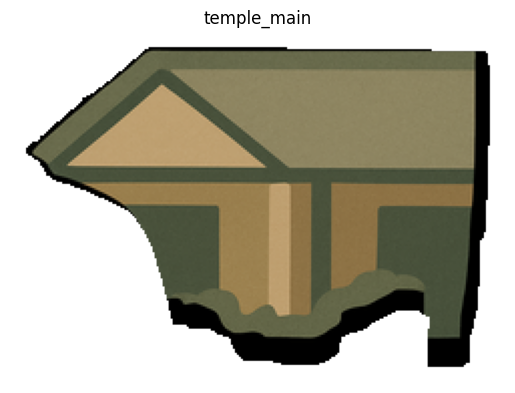

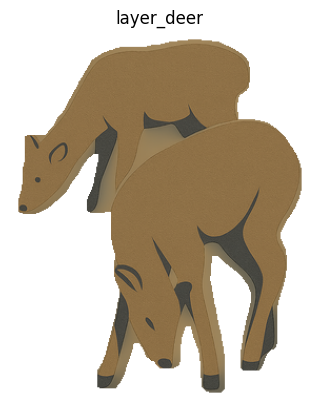

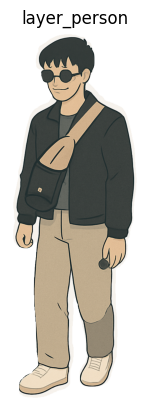

In [102]:
for r in all_results:
    img = Image.open(r["generated_visible_crop_path"])
    plt.imshow(img)
    plt.title(r["layer_name"])
    plt.axis("off")
    plt.show()



Layer: background_sky


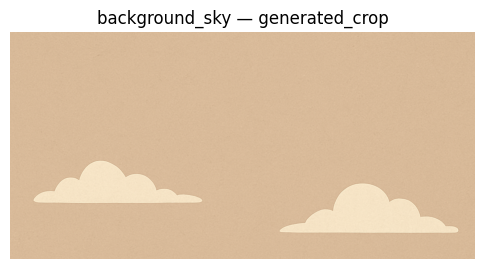

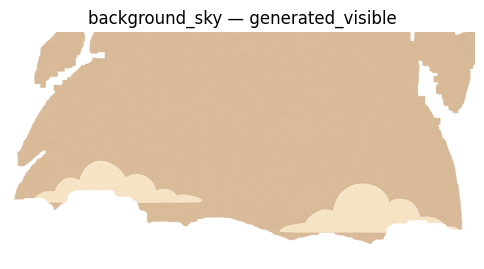

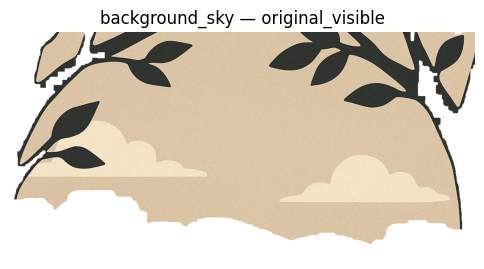


Layer: layer_trees


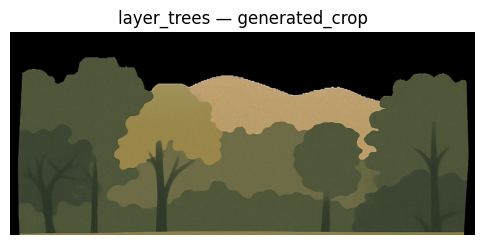

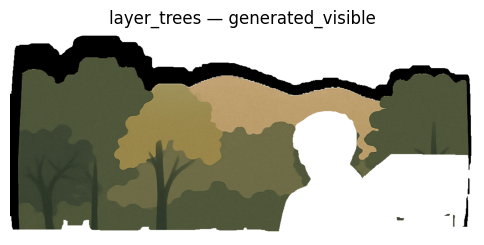

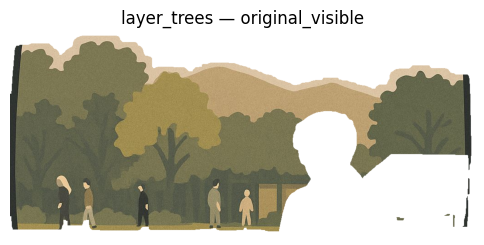


Layer: temple_main


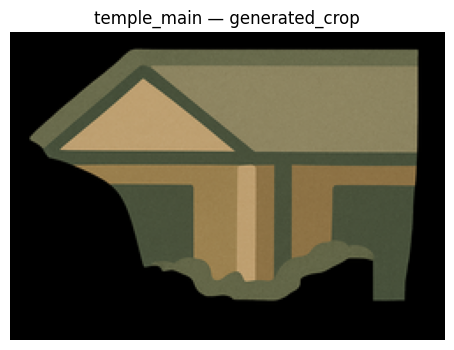

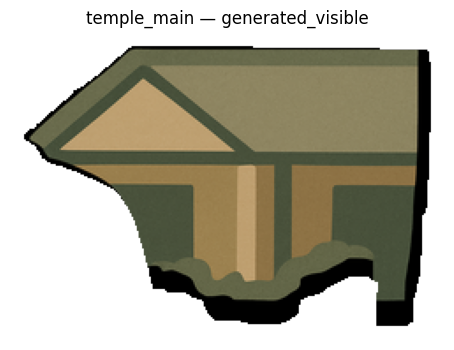

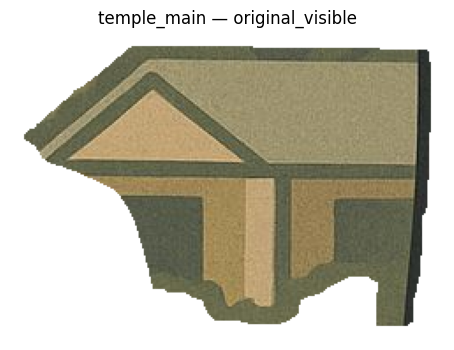


Layer: layer_deer


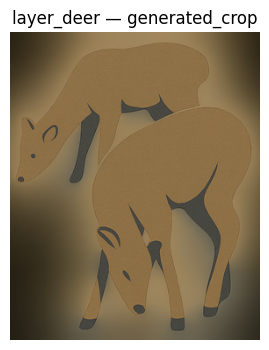

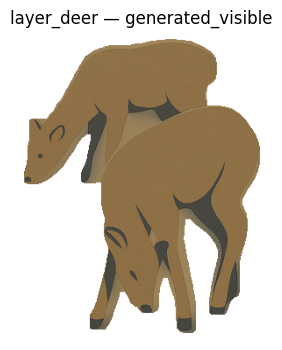

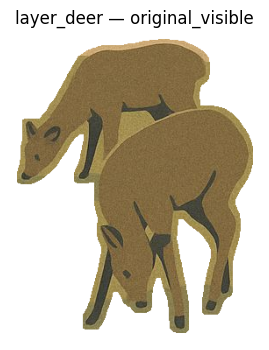


Layer: layer_person


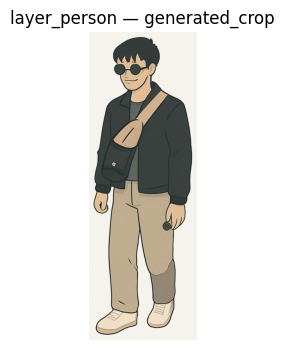

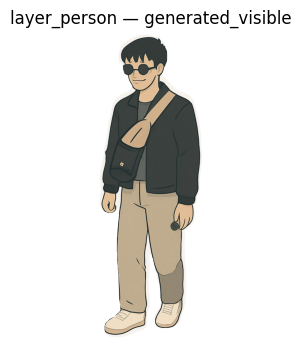

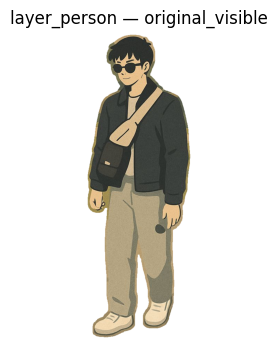

In [103]:
from PIL import Image
import matplotlib.pyplot as plt

for result in all_results:
    print("\n======================")
    print("Layer:", result["layer_name"])
    print("======================")

    paths_to_show = [
        ("generated_crop", result["generated_crop_path"]),
        ("generated_visible", result["generated_visible_crop_path"]),
        ("original_visible", result["original_visible_crop_path"]),
    ]

    for name, p in paths_to_show:
        img = Image.open(p)

        plt.figure(figsize=(6, 4))
        plt.imshow(img)
        plt.title(f"{result['layer_name']} — {name}")
        plt.axis("off")
        plt.show()

In [38]:
print(len(all_results))

0
